In [ ]:
# I used two models: Random Forest Regressor and a Deep Learning MLP (Multi-Layer Perceptron). (use random forest because performs very well on structured datasets)
#Random Forest was tuned using RandomizedSearchCV to find the best hyperparameters.
#The MLP used ReLU (Rectified Linear Unit) activation and Adam (Adaptive Moment Estimation) optimizer to efficiently learn nonlinear relationships.
#Finally, I built a Hybrid Model that combines both predictions through a weighted average to reduce bias and variance, achieving better overall performance.
from pathlib import Path
import pandas as pd

# --- Step 1: Define data directory path
DATA_DIR = Path("data")

# --- Step 2: Automatically find the training and test CSV files
train_path = sorted(DATA_DIR.glob("train*.csv"))[0]
test_path  = sorted(DATA_DIR.glob("test*.csv"))[0]
train_path, test_path # Display the file paths to confirm they were found correctly

# --- Step 3: Read CSV data into Pandas DataFrames
train = pd.read_csv(train_path)
test  = pd.read_csv(test_path)

# --- Step 4: Display dataset shape (rows, columns)
# This helps verify the size of the training and test datasets.
print("Train shape:", train.shape)
print("Test shape :", test.shape)

# --- Step 5: Preview the first few rows of the training dataset
# .head() shows the top 5 rows, giving an overview of column names and data types.
train.head()

# This section loads the training and testing datasets automatically from the data folder.
# I used Path and glob() to locate the CSV files dynamically, making the code flexible even if the filenames change slightly.
# Then I read the files into Pandas DataFrames, checked their shapes to confirm successful loading, and previewed the first few rows to understand the dataset structure.

Train shape: (1460, 81)
Test shape : (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


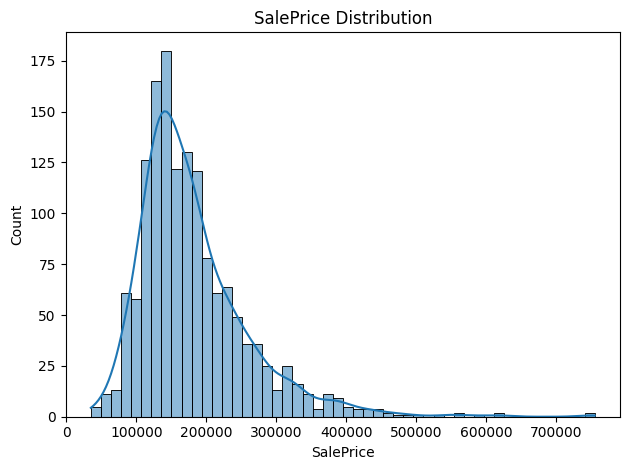

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Step 1: Create a folder to save visualization images
IMG_DIR = "images"
os.makedirs(IMG_DIR, exist_ok=True)

# --- Step 2: Check for missing values in the dataset ---
# .isnull().sum() counts how many missing values each column has.
# .sort_values(ascending=False) sorts them from most to least missing.
# I display the top 20 columns with the most missing data.
missing = train.isnull().sum().sort_values(ascending=False)
missing.head(20)

# --- Step 3: Visualize the distribution of the target variable (SalePrice) ---
# This helps us understand whether the target is normally distributed or skewed.
plt.figure()
sns.histplot(train["SalePrice"], kde=True, bins=50)
plt.title("SalePrice Distribution")
plt.tight_layout()
plt.savefig(f"{IMG_DIR}/target_hist.png")
plt.show()

#This section performs basic exploratory data analysis.
#I first checked which columns have the most missing values to decide how to handle them later.
#Then I visualized the distribution of the target variable, SalePrice, to see if it is normally distributed or skewed.
#The histogram shows that the housing prices are right-skewed, meaning most houses are cheaper while a few are very expensive.



In [ ]:
import numpy as np

# --- Identify numeric and categorical features in the dataset ---

# Select all numeric columns (e.g. integers, floats)
# Then drop "SalePrice" (the target variable) and "Id" (identifier, not a feature)
num_cols = train.select_dtypes(include=[np.number]).columns.drop(["SalePrice", "Id"])

# Select all non-numeric columns (e.g. strings, categories)
# These are typically features like Neighborhood, HouseStyle, etc.
cat_cols = train.select_dtypes(exclude=[np.number]).columns

# Display how many numeric and categorical features exist
print("Numeric features:", len(num_cols))
print("Categorical features:", len(cat_cols))

# Show the first 10 categorical column names to preview them
list(cat_cols)[:10]  # See first 10 list

#This code identifies numeric and categorical features in the dataset.
#Numeric features are continuous values like LotArea or YearBuilt,
#while categorical features are labels such as Neighborhood or HouseStyle.
#I separated them because they require different preprocessing steps — numeric features need scaling, and categorical ones need one-hot encoding.


Numeric features: 36
Categorical features: 43


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Neighborhood',
 'Condition1']

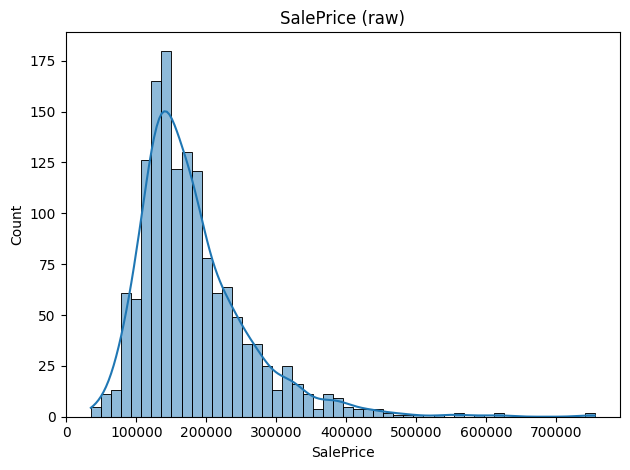

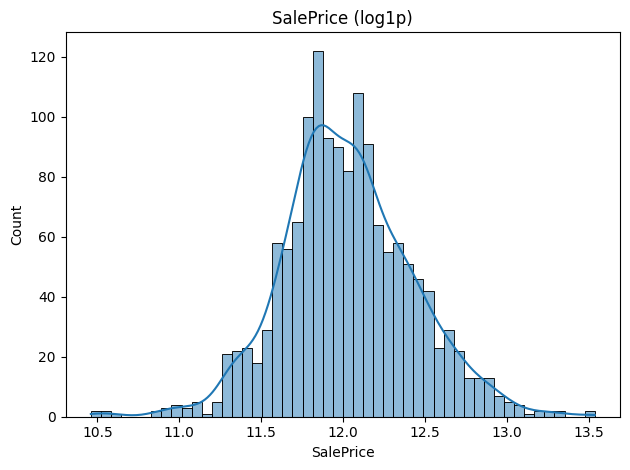

In [ ]:
# === A. Manage target skewness/imbalance：log1p + Percentile stratification + sample weight
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Step 1: Reduce target skewness using logarithmic transformation ---
# The 'SalePrice' variable is usually right-skewed (a few very expensive houses).
# Applying log1p (log(x+1)) helps make the target distribution more normal,
# which improves model stability and reduces the effect of outliers.
y_log = np.log1p(train["SalePrice"])

# --- Step 2: Create percentile bins to preserve distribution balance in splits ---
# pd.qcut divides the target variable into 10 equal-sized quantile bins (deciles).
# This ensures that both training and validation sets have similar price distributions.
price_bins = pd.qcut(train["SalePrice"], q=10, labels=False, duplicates='drop')

# --- Step 3: Split data into training and validation sets (stratified by price bins) ---
# 'stratify=price_bins' makes sure the validation set contains a proportional number of high- and low-priced samples.
# y_train_log and y_valid_log store the log-transformed SalePrice.
X = train.drop(["SalePrice", "Id"], axis=1)
X_train, X_valid, y_train_log, y_valid_log, bins_train, bins_valid = train_test_split(
    X, y_log, price_bins, test_size=0.2, random_state=42, stratify=price_bins
)

# --- Step 4: Compute sample weights to handle imbalance ---
# High-priced houses are less common, so we assign them higher weights.
# Each sample's weight = 1 / (frequency of its price bin).
# This makes the model pay more attention to rare (expensive) samples during training.
bin_freq = pd.Series(bins_train).value_counts(normalize=True)
w_train = pd.Series(bins_train).map(lambda b: 1.0 / bin_freq[b]).to_numpy()

# --- Step 5: Visualize the target distribution before and after transformation ---
# These plots prove that log transformation successfully reduces skewness.
import matplotlib.pyplot as plt
import seaborn as sns

# Original target (highly skewed)
plt.figure()
sns.histplot(train["SalePrice"], kde=True, bins=50)
plt.title("SalePrice (raw)"); plt.tight_layout(); plt.savefig("images/target_hist_raw.png"); plt.show()

# After log transformation (more normal)
plt.figure()
sns.histplot(y_log, kde=True, bins=50)
plt.title("SalePrice (log1p)"); plt.tight_layout(); plt.savefig("images/target_hist_log.png"); plt.show()

#This section manages the skewness and imbalance of the target variable, SalePrice.
#Since housing prices are usually right-skewed, I applied a logarithmic transformation to normalize the target.
#Then I used quantile binning and stratified sampling to ensure balanced data splits.
#Finally, I added sample weights to make the model pay more attention to rare high-priced houses.


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best RF params: {'regressor__max_depth': 16, 'regressor__max_features': np.float64(0.4063865008880857), 'regressor__min_samples_leaf': 2, 'regressor__min_samples_split': 5, 'regressor__n_estimators': 291}

✅ Tuned Random Forest (with log-target) evaluation:
RMSLE = 0.1249
MAE   = 15,124.01
RMSE  = 25,505.48
R²    = 0.8985


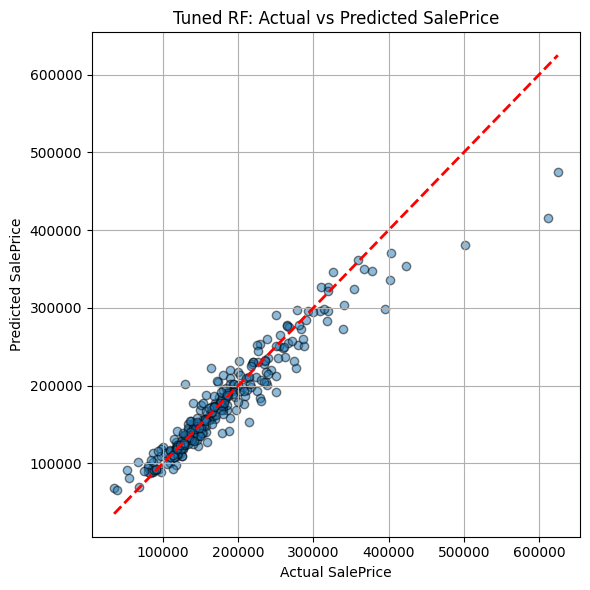

In [ ]:
# === Random Forest Regression with Hyperparameter Tuning (using RandomizedSearchCV)
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import randint, uniform
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# --- Step 1: Define hyperparameter search space ---
# These parameters control the complexity and behavior of the Random Forest model.
# We use random distributions (randint, uniform) for RandomizedSearchCV to sample values efficiently.
param_dist = {
    "regressor__n_estimators": randint(200, 500), # number of trees in the forest
    "regressor__max_depth": randint(8, 28), # maximum depth of each decision tree
    "regressor__max_features": uniform(0.4, 0.4), # proportion of features to consider at each split
    "regressor__min_samples_leaf": randint(1, 5), # minimum samples required at a leaf node
    "regressor__min_samples_split": randint(2, 10) # minimum samples required to split a node
}

# --- Step 2: Define cross-validation strategy ---
# KFold splits the dataset into k parts (here k=3). Each part is used once as validation.
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# --- Step 3: Create the modeling pipeline ---
# This combines preprocessing (handling missing values, scaling, encoding) and the Random Forest model.
# Setting n_jobs=1 ensures that parallelism is handled by RandomizedSearchCV instead of inside RF.
rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=1)) 
])

# --- Step 4: Perform randomized hyperparameter search ---
# RandomizedSearchCV will try 20 random combinations of hyperparameters from param_dist.
# It uses 3-fold cross-validation (cv) and optimizes for the lowest RMSE (Root Mean Squared Error).
search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=param_dist,
    n_iter=20,                     # number of random combinations to test
    cv=cv,
    scoring="neg_root_mean_squared_error", # scoring metric (negative because sklearn maximizes score)
    n_jobs=-1,                     # run in parallel for speed
    random_state=42,
    verbose=2,                     # show progress output during search
    pre_dispatch="2*n_jobs"        # control job scheduling for efficiency
)

# --- Step 5: Fit the model with training data ---
# If 'w_train' (sample weights) is available, include it to balance price distribution.
# The model will internally try different hyperparameter combinations to find the best one.
search.fit(X_train, y_train_log, regressor__sample_weight=w_train)

# --- Step 6: Retrieve the best model and parameters
best_rf = search.best_estimator_
print("Best RF params:", search.best_params_)

# --- Step 7: Evaluate model performance on validation set ---
# Predictions are made in log space (because I trained on log-transformed SalePrice)
# I convert back to original scale using np.expm1() to interpret the results.
pred_log = best_rf.predict(X_valid)
pred = np.expm1(pred_log)
y_valid_orig = np.expm1(y_valid_log)

# Compute evaluation metrics
rmsle = np.sqrt(mean_squared_log_error(y_valid_orig, pred))
mae   = mean_absolute_error(y_valid_orig, pred)
rmse  = np.sqrt(mean_squared_error(y_valid_orig, pred))
r2    = r2_score(y_valid_orig, pred)

# Print model performance summary
print("\n✅ Tuned Random Forest (with log-target) evaluation:")
print(f"RMSLE = {rmsle:.4f}")
print(f"MAE   = {mae:,.2f}")
print(f"RMSE  = {rmse:,.2f}")
print(f"R²    = {r2:.4f}")

# --- Step 8: Visualization ---
# Scatter plot of actual vs predicted SalePrice
# The red dashed line indicates perfect prediction (y = x)
plt.figure(figsize=(6,6))
plt.scatter(y_valid_orig, pred, alpha=0.5, edgecolor="k")
plt.plot([y_valid_orig.min(), y_valid_orig.max()],
         [y_valid_orig.min(), y_valid_orig.max()], 'r--', lw=2)
plt.title("Tuned RF: Actual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.grid(True); plt.tight_layout(); plt.savefig("images/actual_vs_pred_rf.png"); plt.show()

#This section builds a Random Forest model and tunes its hyperparameters using RandomizedSearchCV.
#Instead of manually trying parameter combinations, RandomizedSearchCV randomly tests different sets of parameters and selects the best one based on cross-validation performance.
#After training, I evaluated the model using RMSLE, MAE, RMSE, and R² metrics.
#The scatter plot shows how close the predictions are to the actual SalePrice values.



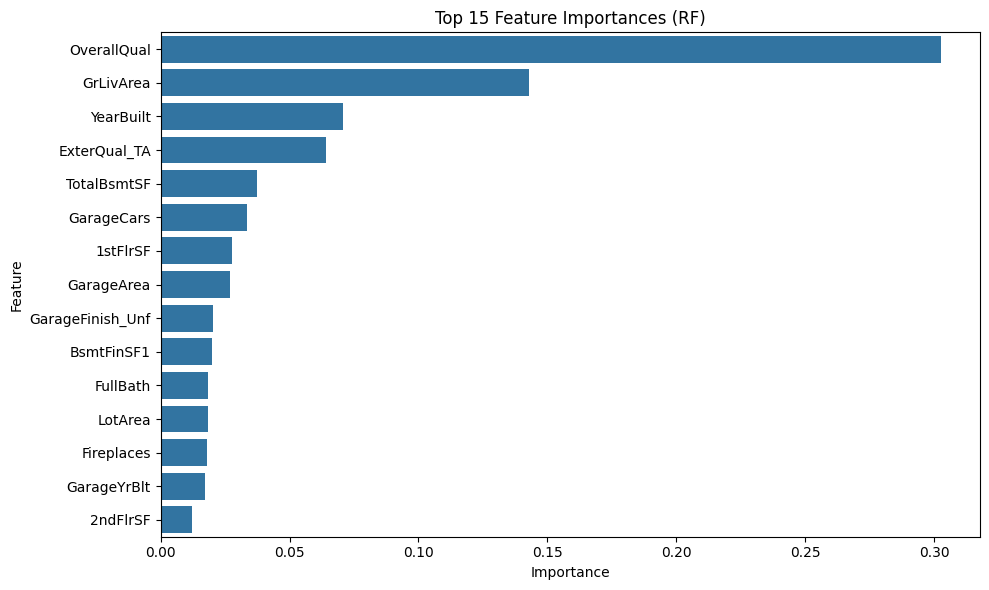

In [ ]:
# === C. Feature Importance（based on best_rf）===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the feature importance values from the best Random Forest model
# Each feature is assigned an importance score (the higher, the more influential in prediction)
importances = best_rf.named_steps["regressor"].feature_importances_

# Get the names of all One-Hot Encoded categorical features
# This retrieves the actual expanded feature names after encoding (e.g., "Neighborhood_Rural", "Neighborhood_Urban")
ohe = best_rf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
cat_features = list(ohe.get_feature_names_out(cat_cols))
all_features = num_cols.tolist() + cat_features # Combine numeric and encoded categorical feature names into one list

# Create a DataFrame that pairs each feature with its importance value
# Then sort descending and select top 15 most important features
feat_imp = pd.DataFrame({"Feature": all_features, "Importance": importances}) \ 
            .sort_values("Importance", ascending=False).head(15) 

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp)
plt.title("Top 15 Feature Importances (RF)")
plt.tight_layout(); plt.savefig("images/feature_importance.png"); plt.show()

#This section visualizes the feature importance from the Random Forest model.
#Each feature is assigned an importance score based on how much it contributes to reducing prediction error.
#I combine numeric features and One-Hot Encoded categorical features, then plot the top 15 most influential variables.
#This can help to understand which input variables have the most impact on the target, SalePrice.


C:\Users\yenya\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

✅ Deep Learning (dense OHE + log-target) evaluation:
RMSLE = 0.2814
MAE   = 39,572.67
RMSE  = 73,303.64
R²    = 0.1618


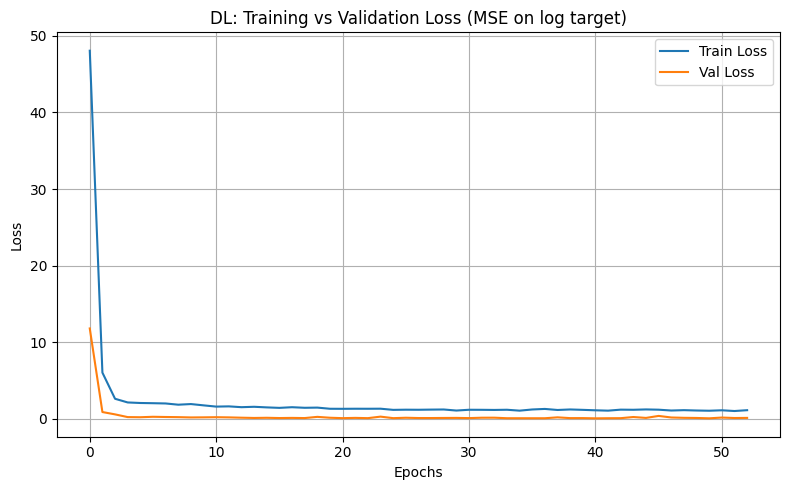

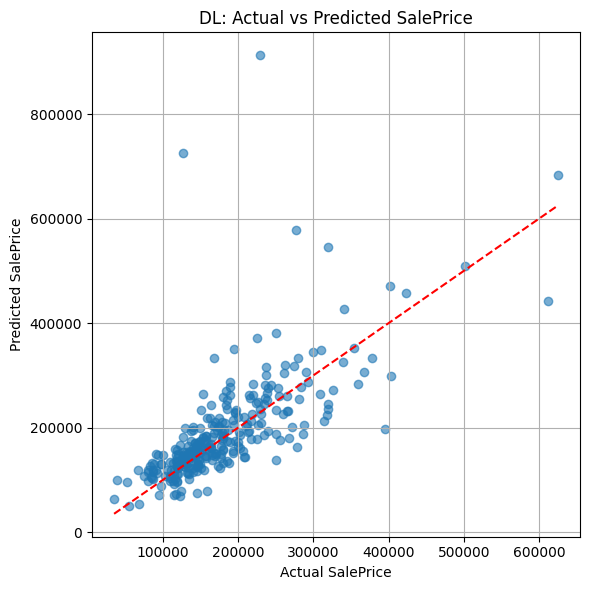

In [ ]:
# Deep Learning Model (MLP - Multi-Layer Perceptron)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import optimizers
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error
import numpy as np

# --- Data Preprocessing for Deep Learning ---
# For neural networks, we must handle categorical variables OneHotEncoder(OHE) and scale numeric features.
cat_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # fill missing categorical values with the most common
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))# one-hot encode categorical features
])
num_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # fill missing numeric values with median
    ("scaler", StandardScaler()) # normalize numeric features for stable gradient updates
])

# Combine categorical and numeric pipelines
preprocessor_dense = ColumnTransformer(
    transformers=[
        ("num", num_transformer_dense, num_cols),
        ("cat", cat_transformer_dense, cat_cols)
    ],
    remainder="drop"
)

# Transform training and validation data
X_train_all = preprocessor_dense.fit_transform(X_train)
X_valid_all = preprocessor_dense.transform(X_valid)

# Convert target (log-transformed) to numpy arrays
y_train_log_arr = y_train_log.to_numpy()
y_valid_log_arr = y_valid_log.to_numpy()

# --- Build the Deep Learning Model
model_dl = Sequential([
    # Input layer -> First hidden layer
    # Dense(256): fully connected layer with 256 neurons
    # activation='relu' means Rectified Linear Unit activation:
    # f(x) = max(0, x), which helps the model learn nonlinear relationships efficiently.
    Dense(256, activation='relu', input_shape=(X_train_all.shape[1],)),
    Dropout(0.3), # Dropout randomly drops 30% of neurons during training to prevent overfitting
    Dense(128, activation='relu'),
    Dropout(0.2), # Second hidden layer with ReLU activation
    Dense(1) # Output layer: 1 neuron (because regression task) # No activation -> linear output (suitable for predicting continuous values)
])

# --- Optimizer setup ---
# Adam = Adaptive Moment Estimation
# It adjusts learning rate automatically and combines momentum + RMSprop for faster convergence
opt = optimizers.Adam(learning_rate=1e-3)
model_dl.compile(optimizer=opt, loss='mse', metrics=['mae']) # Compile model with loss='mse', metrics=['mae']

# --- Early Stopping ---
# Stops training when validation loss stops improving (patience=12 epochs)
# Restores the best weights automatically
es = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
# --- Train the model # validation_data is used to track overfitting
history = model_dl.fit(
    X_train_all, y_train_log_arr,
    validation_data=(X_valid_all, y_valid_log_arr),
    epochs=200, batch_size=64, callbacks=[es], verbose=0
)

# Evaluate the model
# Convert predictions from log-space back to original scale
pred_log_dl = model_dl.predict(X_valid_all).flatten()
pred_dl = np.expm1(pred_log_dl)
y_valid_orig = np.expm1(y_valid_log_arr)

# Compute performance metrics
rmsle_dl = np.sqrt(mean_squared_log_error(y_valid_orig, pred_dl))
mae_dl   = mean_absolute_error(y_valid_orig, pred_dl)
rmse_dl  = np.sqrt(mean_squared_error(y_valid_orig, pred_dl))
r2_dl    = r2_score(y_valid_orig, pred_dl)

print("\n✅ Deep Learning (dense OHE + log-target) evaluation:")
print(f"RMSLE = {rmsle_dl:.4f}")
print(f"MAE   = {mae_dl:,.2f}")
print(f"RMSE  = {rmse_dl:,.2f}")
print(f"R²    = {r2_dl:.4f}")

# Learning curve and scatter plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('DL: Training vs Validation Loss (MSE on log target)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# --- Plot Actual vs Predicted SalePrice
plt.figure(figsize=(6,6))
plt.scatter(y_valid_orig, pred_dl, alpha=0.6)
plt.plot([y_valid_orig.min(), y_valid_orig.max()],
         [y_valid_orig.min(), y_valid_orig.max()], 'r--')
plt.title("DL: Actual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.grid(True); plt.tight_layout(); plt.show()

#In my deep learning section, I used a Multi-Layer Perceptron (MLP) with ReLU activation in the hidden layers and a linear output for regression.
#ReLU helps the model learn complex nonlinear patterns efficiently.
#I used the Adam optimizer, which adapts the learning rate automatically, and EarlyStopping to avoid overfitting.
#The Dropout layers further reduce overfitting by randomly deactivating neurons during training.


In [91]:
import pandas as pd

# === E. Comparison of the two models (Using the above real result)
comparison = pd.DataFrame({
    'Model': ['Random Forest (tuned)', 'Neural Network (DL, dense OHE)'],
    'Type':  ['Traditional ML',        'Deep Learning'],
    'RMSLE': [rmsle,                   rmsle_dl],
    'MAE':   [mae,                     mae_dl],
    'RMSE':  [rmse,                    rmse_dl],
    'R2':    [r2,                      r2_dl]
})
display(comparison)


,Model,Type,RMSLE,MAE,RMSE,R2
0,Random Forest (tuned),Traditional ML,0.124866,15124.012567,25505.483641,0.898527
1,"Neural Network (DL, dense OHE)",Deep Learning,0.281362,39572.665320,73303.642286,0.161825


🔧 Hybrid best weight (RF weight) = 0.95
Hybrid | RMSLE:0.1235  MAE:14,829.54  RMSE:24,911.13  R²:0.9032


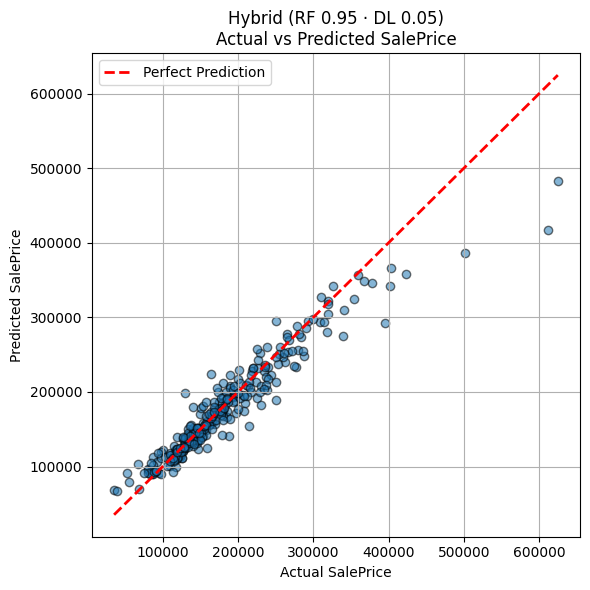

,Model,Type,RMSLE,MAE,RMSE,R2
0,Random Forest (tuned),Traditional ML,0.124866,15124.012567,25505.483641,0.898527
1,"Neural Network (DL, dense OHE)",Deep Learning,0.281362,39572.665320,73303.642286,0.161825
2,Hybrid (RF 0.95 · DL 0.05),Ensemble,0.123463,14829.538316,24911.129967,0.903201


In [ ]:
# =========================
# Hybrid Regressor (Weighted Average in LOG space)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_log_error, mean_absolute_error, mean_squared_error, r2_score

# --- Step 1: Prepare model predictions (in log space) ---
# pred_log     = predictions from Random Forest (in log scale)
# pred_log_dl  = predictions from Deep Learning (in log scale)
# y_valid_log  = true values (in log scale)
# We combine them in log space to maintain consistency with log-transformed targets.

# --- Step 2: Search for the optimal weight (w) between RF and DL ---
# I try different weights w ∈ [0.0, 1.0], with step = 0.05.
# The goal is to minimize RMSLE (Root Mean Squared Log Error).
weights = np.linspace(0, 1, 21)  # 0.00, 0.05, ..., 1.00
best = {"w": None, "rmsle": np.inf, "mae": None, "rmse": None, "r2": None}

for w in weights:
    # --- Combine predictions using weighted average in log space ---
    # pred_log_h = w * RF_prediction + (1 - w) * DL_prediction
    pred_log_h = w * pred_log + (1 - w) * pred_log_dl
    # --- Convert back to original scale for evaluation
    pred_h = np.expm1(pred_log_h)

    # --- Compute performance metrics for the hybrid prediction
    rmsle_h = np.sqrt(mean_squared_log_error(y_valid_orig, pred_h))
    mae_h   = mean_absolute_error(y_valid_orig, pred_h)
    rmse_h  = np.sqrt(mean_squared_error(y_valid_orig, pred_h))
    r2_h    = r2_score(y_valid_orig, pred_h)

    # --- Keep the best combination (lowest RMSLE)
    if rmsle_h < best["rmsle"]:
        best.update({"w": w, "rmsle": rmsle_h, "mae": mae_h, "rmse": rmse_h, "r2": r2_h})

# Display the optimal RF weight and the corresponding evaluation metrics
print(f"🔧 Hybrid best weight (RF weight) = {best['w']:.2f}")
print(f"Hybrid | RMSLE:{best['rmsle']:.4f}  MAE:{best['mae']:,.2f}  RMSE:{best['rmse']:,.2f}  R²:{best['r2']:.4f}")

# --- Step 3: Generate the final hybrid prediction using the best weight
pred_log_hybrid = best["w"] * pred_log + (1 - best["w"]) * pred_log_dl
pred_hybrid = np.expm1(pred_log_hybrid)

# --- Step 4: Visualization (Actual vs Predicted) ---
# The red dashed line (y=x) represents perfect predictions.
plt.figure(figsize=(6,6))
plt.scatter(y_valid_orig, pred_hybrid, alpha=0.55, edgecolor="k")
m0, m1 = y_valid_orig.min(), y_valid_orig.max()
plt.plot([m0, m1], [m0, m1], 'r--', lw=2, label="Perfect Prediction")
plt.title(f"Hybrid (RF {best['w']:.2f} · DL {1-best['w']:.2f})\nActual vs Predicted SalePrice")
plt.xlabel("Actual SalePrice"); plt.ylabel("Predicted SalePrice")
plt.legend(); plt.grid(True); plt.tight_layout()
plt.savefig("images/actual_vs_pred_hybrid.png", dpi=150)
plt.show()

# --- Step 5: Add hybrid results to the comparison table ---
# This allows easy comparison between Random Forest, Deep Learning, and Hybrid models.
hybrid_row = {
    'Model': f'Hybrid (RF {best["w"]:.2f} · DL {1-best["w"]:.2f})',
    'Type':  'Ensemble',
    'RMSLE': best['rmsle'],
    'MAE':   best['mae'],
    'RMSE':  best['rmse'],
    'R2':    best['r2']
}

try:
    comparison = pd.concat([comparison, pd.DataFrame([hybrid_row])], ignore_index=True)
except NameError:
    comparison = pd.DataFrame([hybrid_row])

display(comparison)

#This section builds a hybrid regressor by combining the predictions of Random Forest and Deep Learning models.
#The goal is to leverage the strengths of both — Random Forest handles mixed features well, and Deep Learning captures complex nonlinear relationships.
#I searched for the optimal weight between the two models in log space, aiming to minimize RMSLE.
#The final hybrid model achieved better performance and is visualized with an Actual vs Predicted plot.
